# Nairobi Heat Vulnerability - Statistical Analysis

This notebook **reuses the layers already computed** by the other notebooks
(it does not recompute them from raw data):

| Layer | Source | How it gets here |
|-------|--------|------------------|
| Informal settlements | 1_3 | `results/exposure/...geojson` |
| LST 2020/2022/2024 | 1_1 | `results/lst_geotiffs/*.tif` |
| Wealth (RWI) | 2_1 | `results/web/data/wealth.tif` |
| Proximity x5 + road density + AC composite | 3_1 | `results/web/data/*.tif` |
| Population (raw input) | WorldPop | `data/geospatial/2_sensitivity/*.tif` |

> The `*.tif` grids are written by `export_grid_data()` in 2_1 and 3_1. If a grid
> is missing, **re-run that upstream notebook once** to generate it.

All comparisons are **Informal vs Formal (rest of city)**, restricted to
**inhabited pixels** (population > 0) so empty land does not distort the stats.

Sections: 1 Exposure - 2 Sensitivity - 3 Adaptive Capacity -
4 **Vulnerability synthesis** - 5 Summary.

## 0 - Setup, grids & masks

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.enums import Resampling
from rasterio.warp import reproject
from scipy.stats import mannwhitneyu, ks_2samp
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

sys.path.append("../.")
from src.common_helper import load_boundary, create_analysis_grid, PROJECT_ROOT, DATA_DIR, RESULTS_DIR
from src.sensitivity_helper import resample_to_grid
from src.export_web_maps import load_grid_data

%matplotlib inline

STATS_DIR = os.path.join(RESULTS_DIR, "statistics")
os.makedirs(STATS_DIR, exist_ok=True)

INFORMAL_GJ = os.path.join(RESULTS_DIR, "exposure", "informal_settlements_obia_2024_v12.geojson")
LST = {y: os.path.join(RESULTS_DIR, "lst_geotiffs", f"LST_{y}.tif") for y in (2020, 2022, 2024)}
POP = {
    "general":  os.path.join(DATA_DIR, "2_sensitivity", "nairobi_general_pop_2020.tif"),
    "children": os.path.join(DATA_DIR, "2_sensitivity", "nairobi_children_pop_2020.tif"),
    "elderly":  os.path.join(DATA_DIR, "2_sensitivity", "nairobi_elderly_pop_2020.tif"),
}

ZONES = ["Informal", "Formal (non-informal)"]
COLORS = {"Informal": "#d73027", "Formal (non-informal)": "#4393c3"}
print("Paths set.")

Paths set.


In [2]:
# --- Grid & masks ----------------------------------------------------------
boundary = load_boundary()
grid = create_analysis_grid(boundary, resolution_m=50)
pixel_area_ha = (grid["resolution"] ** 2) / 10_000

# Informal mask from the 1_3 output
informal_gdf = gpd.read_file(INFORMAL_GJ).to_crs(grid["crs"])
informal_raster = rasterize(
    [(g, 1) for g in informal_gdf.geometry if g is not None],
    out_shape=(grid["nrows"], grid["ncols"]), transform=grid["transform"],
    fill=0, dtype="uint8").astype(bool)

# Inhabited mask from raw WorldPop (raw input, identical to what 2_1 reads)
pop_general = resample_to_grid(POP["general"], grid, method=Resampling.sum)
if pop_general is not None:
    pop_mask = (pop_general > 0) & grid["mask"]
else:
    print("WARNING: population raster missing - using full city as inhabited mask")
    pop_mask = grid["mask"].copy()

informal_mask = informal_raster & pop_mask
formal_mask   = ~informal_raster & pop_mask
MASKS = {"Informal": informal_mask, "Formal (non-informal)": formal_mask}

print(f"Inhabited cells : {pop_mask.sum():,} ({pop_mask.sum()/grid['mask'].sum()*100:.1f}% of city)")
print(f"Informal        : {informal_mask.sum():,} cells | {informal_mask.sum()*pixel_area_ha:,.0f} ha")
print(f"Formal          : {formal_mask.sum():,} cells | {formal_mask.sum()*pixel_area_ha:,.0f} ha")

  Grid created: 631 x 982 cells (50 m resolution)
Inhabited cells : 146,675 (52.7% of city)
Informal        : 2,565 cells | 641 ha
Formal          : 144,110 cells | 36,028 ha


In [3]:
# --- Loaders ---------------------------------------------------------------
def load_lst(year):
    """Reproject an LST GeoTIFF onto the analysis grid."""
    path = LST[year]
    if not os.path.exists(path):
        print(f"  LST {year} missing: {path}")
        return None
    with rasterio.open(path) as src:
        dst = np.full((grid["nrows"], grid["ncols"]), np.nan, np.float32)
        reproject(rasterio.band(src, 1), dst,
                  src_transform=src.transform, src_crs=src.crs,
                  dst_transform=grid["transform"], dst_crs=grid["crs"],
                  resampling=Resampling.bilinear)
    dst[~grid["mask"]] = np.nan
    return dst

def load_layer(name):
    """Load a saved grid (results/web/data/<name>.tif) written by 2_1/3_1."""
    arr = load_grid_data(name, grid)
    if arr is None:
        print(f"  MISSING grid '{name}.tif' - re-run the upstream notebook to generate it.")
    return arr

def zone_values(arr, zone):
    v = arr[MASKS[zone]]
    return v[np.isfinite(v)]

def describe(arr, value_name):
    """Mean/median/std/percentiles per zone for a grid."""
    rows = []
    for z in ZONES:
        v = zone_values(arr, z)
        if len(v) == 0:
            continue
        rows.append({"zone": z, "metric": value_name, "n": len(v),
                     "mean": float(np.mean(v)), "median": float(np.median(v)),
                     "std": float(np.std(v)), "p10": float(np.percentile(v, 10)),
                     "p90": float(np.percentile(v, 90))})
    return pd.DataFrame(rows)

print("Loaders ready.")

Loaders ready.


---
## 1 - Exposure: Land Surface Temperature

The **heat penalty** of living in an informal settlement, plus a multi-year trend
and significance tests.

In [4]:
lst_2024 = load_lst(2024)
inf = zone_values(lst_2024, "Informal")
form = zone_values(lst_2024, "Formal (non-informal)")

gap = inf.mean() - form.mean()
print(f"Informal mean LST : {inf.mean():.2f} C")
print(f"Formal   mean LST : {form.mean():.2f} C")
print(f"HEAT PENALTY (Informal - Formal): {gap:+.2f} C")

u, p_mwu = mannwhitneyu(inf, form, alternative="two-sided")
d, p_ks  = ks_2samp(inf, form)
print(f"Mann-Whitney U p = {p_mwu:.2e}   |   KS D = {d:.3f}, p = {p_ks:.2e}")

# Share of each zone hotter than the city-wide 90th percentile
city = lst_2024[pop_mask]; city = city[np.isfinite(city)]
hot_thr = np.percentile(city, 90)
print(f"\nCity-wide 90th-pct LST = {hot_thr:.1f} C")
for z, v in [("Informal", inf), ("Formal", form)]:
    print(f"  {z}: {(v > hot_thr).mean()*100:.1f}% of cells above it")

lst_df = describe(lst_2024, "LST_2024_C")
lst_df.to_csv(os.path.join(STATS_DIR, "lst_stats_2024.csv"), index=False)
lst_df

Informal mean LST : 40.72 C
Formal   mean LST : 35.91 C
HEAT PENALTY (Informal - Formal): +4.81 C
Mann-Whitney U p = 0.00e+00   |   KS D = 0.579, p = 0.00e+00

City-wide 90th-pct LST = 40.7 C
  Informal: 53.4% of cells above it
  Formal: 9.2% of cells above it


,zone,metric,n,mean,median,std,p10,p90
0,Informal,LST_2024_C,2565,40.718311,40.899895,2.124903,37.969109,43.226526
1,Formal (non-informal),LST_2024_C,144110,35.906387,36.294102,3.855732,30.499254,40.590448


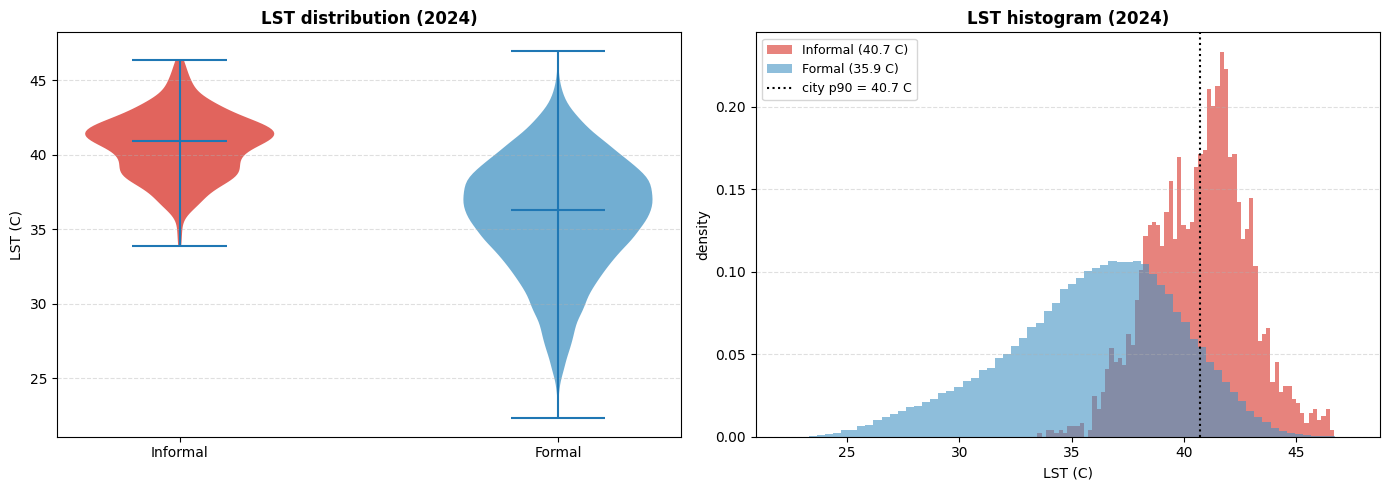

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
parts = axes[0].violinplot([inf[::5], form[::5]], positions=[1, 2], showmedians=True)
for pc, c in zip(parts["bodies"], [COLORS["Informal"], COLORS["Formal (non-informal)"]]):
    pc.set_facecolor(c); pc.set_alpha(0.75)
axes[0].set_xticks([1, 2]); axes[0].set_xticklabels(["Informal", "Formal"])
axes[0].set_ylabel("LST (C)"); axes[0].set_title("LST distribution (2024)", fontweight="bold")
axes[0].grid(axis="y", ls="--", alpha=0.4)

axes[1].hist(inf, bins=70, density=True, alpha=0.6, color=COLORS["Informal"], label=f"Informal ({inf.mean():.1f} C)")
axes[1].hist(form, bins=70, density=True, alpha=0.6, color=COLORS["Formal (non-informal)"], label=f"Formal ({form.mean():.1f} C)")
axes[1].axvline(hot_thr, color="black", ls=":", label=f"city p90 = {hot_thr:.1f} C")
axes[1].set_xlabel("LST (C)"); axes[1].set_ylabel("density")
axes[1].set_title("LST histogram (2024)", fontweight="bold"); axes[1].legend(fontsize=9)
axes[1].grid(axis="y", ls="--", alpha=0.4)
plt.tight_layout(); fig.savefig(os.path.join(STATS_DIR, "lst_distribution_2024.png"), dpi=150); plt.show()

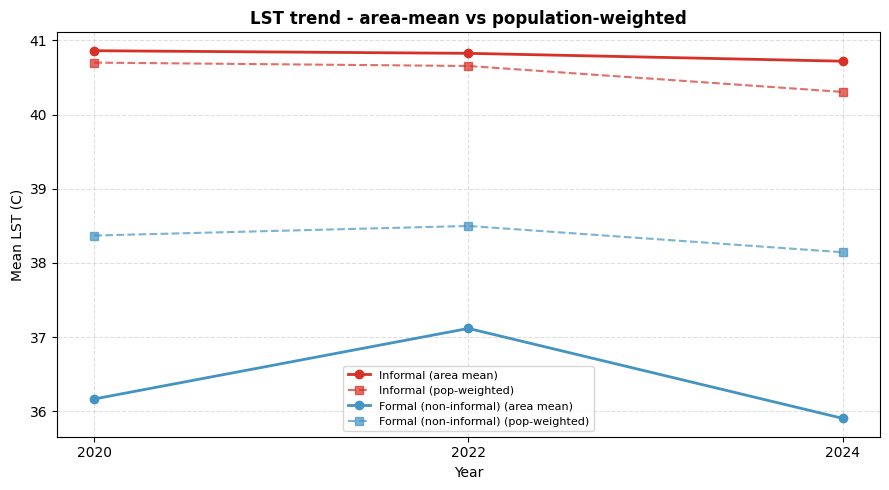

,year,zone,mean_C,pop_weighted_C
0,2020,Informal,40.859428,40.699043
1,2020,Formal (non-informal),36.167412,38.369186
2,2022,Informal,40.824154,40.653633
3,2022,Formal (non-informal),37.117954,38.498512
4,2024,Informal,40.718311,40.304268
5,2024,Formal (non-informal),35.906387,38.144150


In [6]:
# Multi-year trend + population-weighted LST (temperature the average resident feels)
rows = []
for y in (2020, 2022, 2024):
    arr = load_lst(y)
    if arr is None:
        continue
    for z in ZONES:
        v = zone_values(arr, z)
        row = {"year": y, "zone": z, "mean_C": float(v.mean())}
        if pop_general is not None:
            t = arr[MASKS[z]]; pp = pop_general[MASKS[z]]
            ok = np.isfinite(t) & np.isfinite(pp) & (pp > 0)
            row["pop_weighted_C"] = float(np.sum(t[ok]*pp[ok]) / np.sum(pp[ok]))
        rows.append(row)
trend_df = pd.DataFrame(rows)
trend_df.to_csv(os.path.join(STATS_DIR, "lst_trend.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, 5))
for z in ZONES:
    s = trend_df[trend_df["zone"] == z]
    ax.plot(s["year"], s["mean_C"], "o-", color=COLORS[z], lw=2, label=f"{z} (area mean)")
    if "pop_weighted_C" in s:
        ax.plot(s["year"], s["pop_weighted_C"], "s--", color=COLORS[z], lw=1.5, alpha=0.7,
                label=f"{z} (pop-weighted)")
ax.set_xlabel("Year"); ax.set_ylabel("Mean LST (C)"); ax.set_xticks([2020, 2022, 2024])
ax.set_title("LST trend - area-mean vs population-weighted", fontweight="bold")
ax.legend(fontsize=8); ax.grid(ls="--", alpha=0.4)
plt.tight_layout(); fig.savefig(os.path.join(STATS_DIR, "lst_trend.png"), dpi=150); plt.show()
trend_df

---
## 2 - Sensitivity: Population & Wealth

Who is exposed (counts, density, vulnerable age groups) and how poor they are.

In [7]:
city_pop = float(np.nansum(pop_general[pop_mask])) if pop_general is not None else float("nan")
city_area = pop_mask.sum() * pixel_area_ha

rows = []
for name, path in POP.items():
    arr = resample_to_grid(path, grid, method=Resampling.sum)
    if arr is None:
        print(f"  {name}: raster missing"); continue
    for z in ZONES:
        v = arr[MASKS[z]]; v = v[np.isfinite(v)]
        total = float(np.nansum(v)); area = MASKS[z].sum() * pixel_area_ha
        rows.append({"layer": name, "zone": z, "total_people": total,
                     "area_ha": area, "density_per_ha": total/area if area else np.nan,
                     "pct_of_city_pop": total/city_pop*100 if (name == "general" and city_pop) else np.nan})
        print(f"  {name:9s} | {z:22s}: {total:>10,.0f} people  ({total/area:.1f}/ha)")
pop_df = pd.DataFrame(rows)
pop_df.to_csv(os.path.join(STATS_DIR, "sensitivity_population.csv"), index=False)

# --- HEADLINE: informal settlements vs the WHOLE inhabited city -------------
g = pop_df[pop_df.layer == "general"]
if pop_general is not None and not g.empty:
    inf_pop = g[g.zone == "Informal"]["total_people"].values[0]
    inf_area = MASKS["Informal"].sum() * pixel_area_ha
    dens_inf, dens_city = inf_pop / inf_area, city_pop / city_area
    print("\n=== HEADLINE: informal settlements vs whole inhabited city ===")
    print(f"  Population : {inf_pop:,.0f} of {city_pop:,.0f}  = {inf_pop/city_pop*100:.1f}% of city residents")
    print(f"  Land area  : {inf_area:,.0f} of {city_area:,.0f} ha = {inf_area/city_area*100:.1f}% of inhabited land")
    print(f"  Density    : {dens_inf:.0f}/ha informal vs {dens_city:.0f}/ha city avg "
          f"-> {dens_inf/dens_city:.1f}x denser")
pop_df

  general   | Informal              :    320,432 people  (499.7/ha)
  general   | Formal (non-informal) :  4,702,556 people  (130.5/ha)
  children  | Informal              :     57,694 people  (90.0/ha)
  children  | Formal (non-informal) :    847,919 people  (23.5/ha)
  elderly   | Informal              :     13,626 people  (21.2/ha)
  elderly   | Formal (non-informal) :    201,976 people  (5.6/ha)

=== HEADLINE: informal settlements vs whole inhabited city ===
  Population : 320,432 of 5,022,988  = 6.4% of city residents
  Land area  : 641 of 36,669 ha = 1.7% of inhabited land
  Density    : 500/ha informal vs 137/ha city avg -> 3.6x denser


,layer,zone,total_people,area_ha,density_per_ha,pct_of_city_pop
0,general,Informal,3.204323e+05,641.25,499.699513,6.379316
1,general,Formal (non-informal),4.702556e+06,36027.50,130.526848,93.620680
2,children,Informal,5.769388e+04,641.25,89.970955,NaN
3,children,Formal (non-informal),8.479188e+05,36027.50,23.535322,NaN
4,elderly,Informal,1.362610e+04,641.25,21.249278,NaN
5,elderly,Formal (non-informal),2.019763e+05,36027.50,5.606170,NaN


CAVEAT: RWI ~2.4 km resolution -> informal vs formal difference is not reliable.


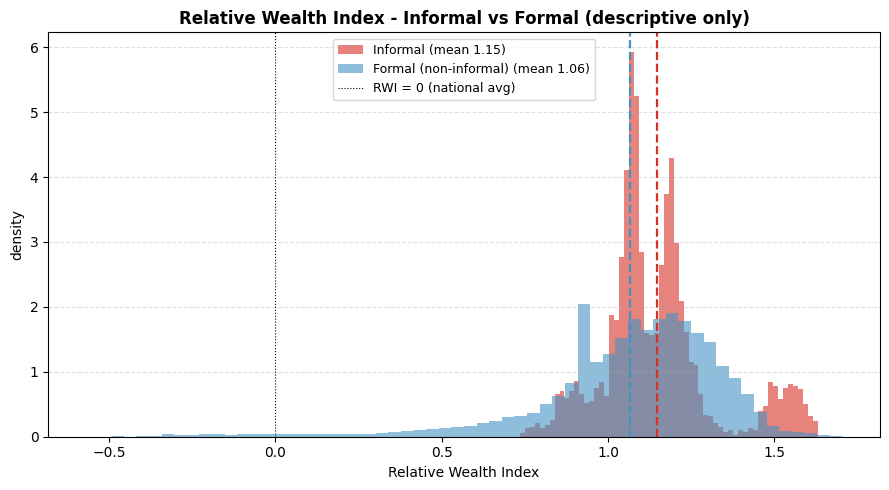

,zone,metric,n,mean,median,std,p10,p90
0,Informal,RWI,2565,1.147432,1.111247,0.171658,0.965547,1.469589
1,Formal (non-informal),RWI,144110,1.064682,1.107684,0.283673,0.757283,1.352588


In [8]:
# Wealth - REUSE the saved grid from 2_1 (no re-interpolation here).
# CAVEAT: Meta RWI native resolution is ~2.4 km - far coarser than a settlement -
# so it CANNOT distinguish informal from adjacent formal (they share a tile).
# Shown here descriptively only; it is excluded from the Section 4 composite.
wealth = load_layer("wealth")
wealth_df = None
if wealth is not None:
    wealth_df = describe(wealth, "RWI")
    print("CAVEAT: RWI ~2.4 km resolution -> informal vs formal difference is not reliable.")
    fig, ax = plt.subplots(figsize=(9, 5))
    for z in ZONES:
        v = zone_values(wealth, z)
        ax.hist(v, bins=60, density=True, alpha=0.6, color=COLORS[z],
                label=f"{z} (mean {v.mean():.2f})")
        ax.axvline(v.mean(), color=COLORS[z], ls="--", lw=1.6)
    ax.axvline(0, color="black", lw=0.8, ls=":", label="RWI = 0 (national avg)")
    ax.set_xlabel("Relative Wealth Index"); ax.set_ylabel("density")
    ax.set_title("Relative Wealth Index - Informal vs Formal (descriptive only)", fontweight="bold")
    ax.legend(fontsize=9); ax.grid(axis="y", ls="--", alpha=0.4)
    plt.tight_layout(); fig.savefig(os.path.join(STATS_DIR, "sensitivity_wealth.png"), dpi=150); plt.show()
    wealth_df.to_csv(os.path.join(STATS_DIR, "sensitivity_wealth.csv"), index=False)
wealth_df

---
## 3 - Adaptive Capacity: Access to services

Reuses the proximity **scores** from 3_1 (1 = closest). **Read these as
CENTRALITY, not access quality.** Informal settlements are central and dense, so
they sit physically close to mapped facilities and score high - but that does
**not** mean residents have good real access. It ignores cost, crowding,
queueing, service quality, and the known under-mapping of informal-area services
in OSM. Treat "informal is closer" as "informal is central".

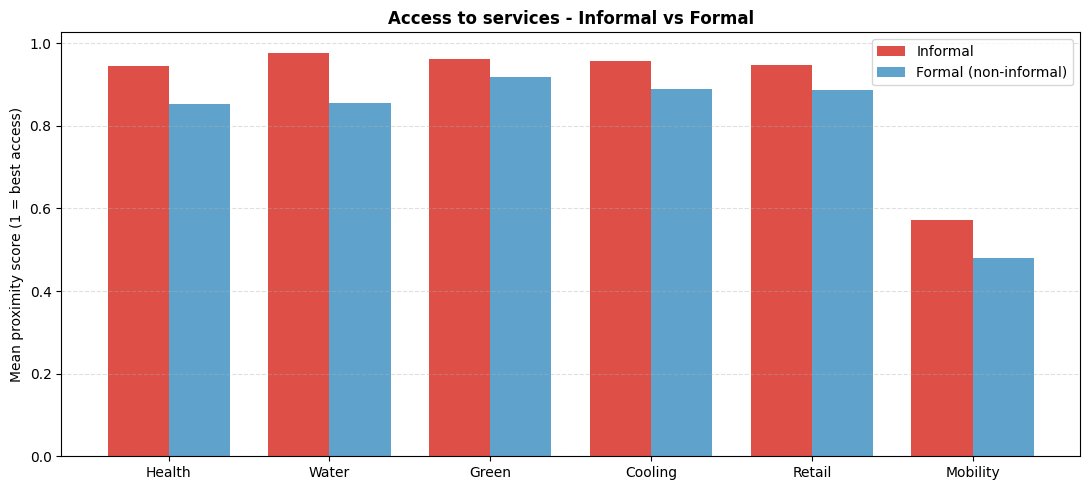

,service,zone,mean_score,median_score
0,Health,Informal,0.946145,0.946728
1,Health,Formal (non-informal),0.852852,0.912950
2,Water,Informal,0.977585,0.994150
3,Water,Formal (non-informal),0.855715,0.910704
4,Green,Informal,0.962421,0.970212
5,Green,Formal (non-informal),0.919126,0.976158
6,Cooling,Informal,0.957372,0.984570
7,Cooling,Formal (non-informal),0.888533,0.920570
8,Retail,Informal,0.948455,0.966821
9,Retail,Formal (non-informal),0.887661,0.911786


In [9]:
AC_LAYERS = {
    "Health":   "health_proximity",
    "Water":    "water_proximity",
    "Green":    "green_proximity",
    "Cooling":  "cooling_proximity",
    "Retail":   "retail_proximity",
    "Mobility": "mobility_proximity",
}
rows = []
ac_grids = {}
for label, name in AC_LAYERS.items():
    arr = load_layer(name)
    if arr is None:
        continue
    ac_grids[label] = arr
    for z in ZONES:
        v = zone_values(arr, z)
        rows.append({"service": label, "zone": z, "mean_score": float(v.mean()),
                     "median_score": float(np.median(v))})
ac_df = pd.DataFrame(rows)
ac_df.to_csv(os.path.join(STATS_DIR, "adaptive_capacity_scores.csv"), index=False)

if not ac_df.empty:
    services = ac_df["service"].unique()
    x = np.arange(len(services)); w = 0.38
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, z in enumerate(ZONES):
        s = ac_df[ac_df["zone"] == z]
        vals = [s[s["service"] == sv]["mean_score"].values[0] for sv in services]
        ax.bar(x + i*w, vals, w, label=z, color=COLORS[z], alpha=0.85)
    ax.set_xticks(x + w/2); ax.set_xticklabels(services)
    ax.set_ylabel("Mean proximity score (1 = best access)")
    ax.set_title("Access to services - Informal vs Formal", fontweight="bold")
    ax.legend(); ax.grid(axis="y", ls="--", alpha=0.4)
    plt.tight_layout(); fig.savefig(os.path.join(STATS_DIR, "adaptive_capacity_scores.png"), dpi=150); plt.show()
ac_df

### 3b - Distance to nearest service (centrality, not access quality)

Real distances from the `*_distance.tif` grids. Informal settlements are
**central**, so they are physically closer to mapped facilities - read this as a
*centrality* signal. It does not capture cost, crowding, service quality, or the
under-mapping of services inside informal areas. (Road density has no distance.)

  Health  : informal    858 m  |  formal   2344 m  (diff -1486 m)
  Water   : informal    271 m  |  formal   1744 m  (diff -1473 m)
  Green   : informal    505 m  |  formal   1086 m  (diff -581 m)
  Cooling : informal    276 m  |  formal    722 m  (diff -446 m)
  Retail  : informal    418 m  |  formal    912 m  (diff -493 m)


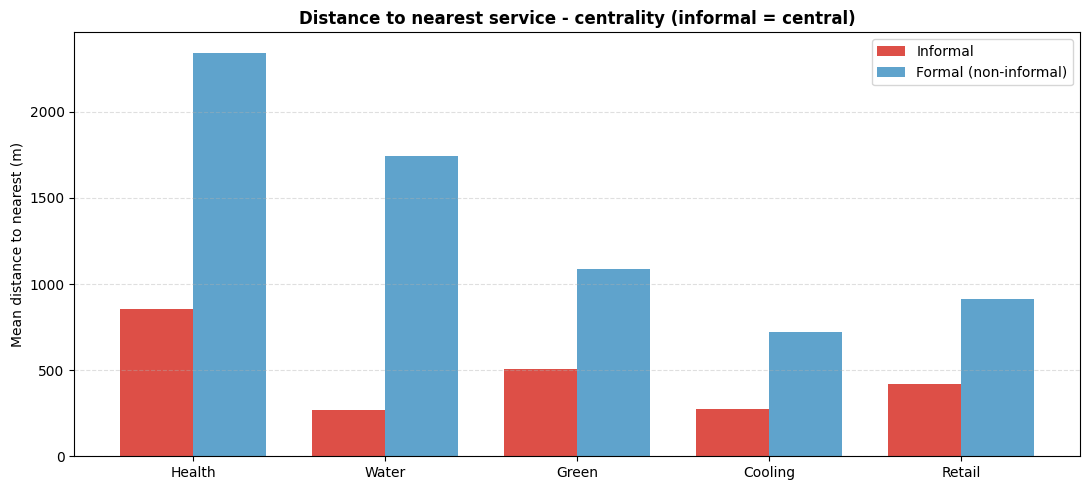

,service,zone,mean_dist_m,median_dist_m,pct_within_1km
0,Health,Informal,857.809753,848.528137,63.157895
1,Health,Formal (non-informal),2343.794434,1386.542480,37.833599
2,Water,Informal,270.937134,70.710678,91.461988
3,Water,Formal (non-informal),1744.012329,1079.351685,47.007147
4,Green,Informal,504.615112,400.000000,87.368421
5,Green,Formal (non-informal),1085.980713,320.156219,74.665186
6,Cooling,Informal,276.270996,100.000000,93.333333
7,Cooling,Formal (non-informal),722.406921,514.781494,77.203525
8,Retail,Informal,418.312225,269.258240,89.707602
9,Retail,Formal (non-informal),911.676941,715.891052,64.725557


In [10]:
# Real distance (metres) to nearest facility - a CENTRALITY signal.
DIST_LAYERS = {"Health": "health_distance", "Water": "water_distance",
               "Green": "green_distance", "Cooling": "cooling_distance",
               "Retail": "retail_distance"}
rows = []
for label, name in DIST_LAYERS.items():
    arr = load_layer(name)
    if arr is None:
        continue
    for z in ZONES:
        v = zone_values(arr, z)
        rows.append({"service": label, "zone": z, "mean_dist_m": float(v.mean()),
                     "median_dist_m": float(np.median(v)),
                     "pct_within_1km": float((v < 1000).mean() * 100)})
dist_df = pd.DataFrame(rows)
dist_df.to_csv(os.path.join(STATS_DIR, "adaptive_capacity_distance.csv"), index=False)

if not dist_df.empty:
    for label in dist_df["service"].unique():
        s = dist_df[dist_df["service"] == label]
        di = s[s.zone == "Informal"]["mean_dist_m"].values[0]
        do = s[s.zone == "Formal (non-informal)"]["mean_dist_m"].values[0]
        print(f"  {label:8s}: informal {di:6.0f} m  |  formal {do:6.0f} m  (diff {di-do:+.0f} m)")

    services = dist_df["service"].unique(); x = np.arange(len(services)); w = 0.38
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, z in enumerate(ZONES):
        s = dist_df[dist_df.zone == z]
        vals = [s[s.service == sv]["mean_dist_m"].values[0] for sv in services]
        ax.bar(x + i*w, vals, w, label=z, color=COLORS[z], alpha=0.85)
    ax.set_xticks(x + w/2); ax.set_xticklabels(services)
    ax.set_ylabel("Mean distance to nearest (m)")
    ax.set_title("Distance to nearest service - centrality (informal = central)", fontweight="bold")
    ax.legend(); ax.grid(axis="y", ls="--", alpha=0.4)
    plt.tight_layout(); fig.savefig(os.path.join(STATS_DIR, "adaptive_capacity_distance.png"), dpi=150); plt.show()
dist_df

---
## 4 - Vulnerability synthesis

`Vulnerability = Exposure x Sensitivity x (lack of Adaptive Capacity)` (IPCC).

- **Exposure** = LST 2024 (hotter -> higher)
- **Sensitivity** = **population density** (more people exposed -> higher).
  Wealth (RWI) is **excluded** here: its ~2.4 km resolution cannot resolve a
  settlement, so it would only add noise. The RWI comparison stays in Section 2
  as a descriptive figure.
- **Adaptive capacity** = the 3_1 composite (`1 - AC`). ⚠ This carries the
  **centrality bias** flagged in Section 3, so the AC term flatters central
  informal areas - interpret the composite with that caveat.

Each pillar is min-max normalised over inhabited pixels, then combined.

In [11]:
def norm01(arr):
    v = arr[pop_mask]; v = v[np.isfinite(v)]
    lo, hi = np.percentile(v, 2), np.percentile(v, 98)
    out = np.clip((arr - lo) / (hi - lo + 1e-9), 0, 1)
    out[~pop_mask] = np.nan
    return out

ac_comp = load_layer("adaptive_capacity_composite")

# Exposure = heat. Sensitivity = population density only (wealth EXCLUDED - RWI
# too coarse to resolve a settlement). AC = 3_1 composite (carries centrality bias).
E = norm01(lst_2024)
pop_dens = pop_general / pixel_area_ha if pop_general is not None else None
S = norm01(pop_dens) if pop_dens is not None else np.zeros_like(E)
AC_lack = 1 - norm01(ac_comp) if ac_comp is not None else None

if AC_lack is not None:
    V = E * S * AC_lack
else:
    print("AC composite missing -> vulnerability = Exposure x Sensitivity only")
    V = E * S
V[~pop_mask] = np.nan

vuln_rows = []
for z in ZONES:
    for label, arr in [("exposure", E), ("sensitivity", S), ("vulnerability", V)]:
        v = zone_values(arr, z)
        vuln_rows.append({"zone": z, "pillar": label, "mean": float(v.mean()), "median": float(np.median(v))})
vuln_df = pd.DataFrame(vuln_rows)
vuln_df.to_csv(os.path.join(STATS_DIR, "vulnerability_pillars.csv"), index=False)

vi = zone_values(V, "Informal").mean(); vf = zone_values(V, "Formal (non-informal)").mean()
print(f"Mean vulnerability - Informal: {vi:.3f} | Formal: {vf:.3f} | ratio x{vi/vf:.2f}")

# Heat-risk hotspot = hot AND densely populated (the two un-confounded pillars;
# wealth excluded, access excluded due to its centrality bias).
if pop_dens is not None:
    hot   = lst_2024 >= np.nanpercentile(lst_2024[pop_mask], 66)
    dense = pop_dens  >= np.nanpercentile(pop_dens[pop_mask], 66)
    hotspot = hot & dense & pop_mask
    for z in ZONES:
        share = (hotspot & MASKS[z]).sum() / MASKS[z].sum() * 100
        print(f"  Heat-risk hotspot share (hot + densely populated) - {z}: {share:.1f}%")
vuln_df

Mean vulnerability - Informal: 0.026 | Formal: 0.009 | ratio x2.75
  Heat-risk hotspot share (hot + densely populated) - Informal: 83.3%
  Heat-risk hotspot share (hot + densely populated) - Formal (non-informal): 18.6%


,zone,pillar,mean,median
0,Informal,exposure,0.855444,0.877045
1,Informal,sensitivity,0.467713,0.428326
2,Informal,vulnerability,0.025874,0.022690
3,Formal (non-informal),exposure,0.560551,0.584735
4,Formal (non-informal),sensitivity,0.125432,0.045174
5,Formal (non-informal),vulnerability,0.009413,0.004000


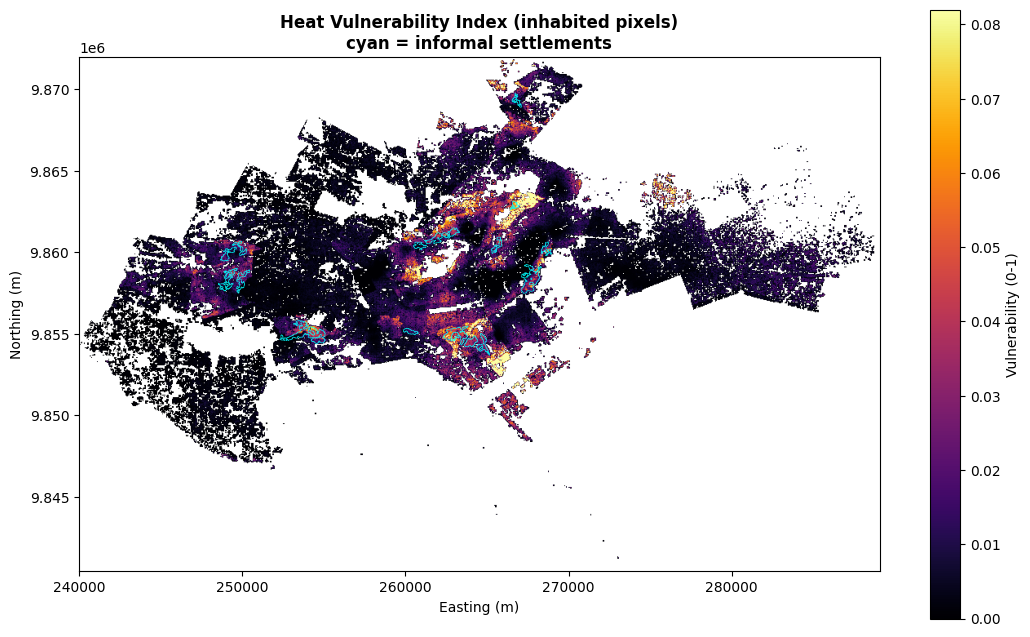

In [12]:
# Vulnerability map (inhabited only) with informal outline
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(V, cmap="inferno", extent=[grid["bounds"][0], grid["bounds"][2],
                                          grid["bounds"][1], grid["bounds"][3]],
               vmin=0, vmax=np.nanpercentile(V, 99))
informal_gdf.boundary.plot(ax=ax, color="cyan", linewidth=0.5, alpha=0.8)
ax.set_title("Heat Vulnerability Index (inhabited pixels)\ncyan = informal settlements",
             fontweight="bold")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.colorbar(im, ax=ax, label="Vulnerability (0-1)", shrink=0.7)
plt.tight_layout(); 
fig.savefig(os.path.join(STATS_DIR, "vulnerability_map.png"), dpi=150); 
plt.show();

---
## 5 - Summary table & dashboard

In [13]:
summary = []
for z in ZONES:
    r = {"zone": z, "area_ha": MASKS[z].sum() * pixel_area_ha}
    iv = zone_values(lst_2024, z)
    r["lst_mean_C"] = float(iv.mean()); r["lst_p95_C"] = float(np.percentile(iv, 95))
    if pop_general is not None:
        sub = pop_df[(pop_df.zone == z) & (pop_df.layer == "general")]
        if not sub.empty:
            r["population"] = float(sub.total_people.values[0])
            r["density_per_ha"] = float(sub.density_per_ha.values[0])
    if wealth is not None:
        r["rwi_mean"] = float(zone_values(wealth, z).mean())
    for label, arr in ac_grids.items():
        r[f"{label.lower()}_access"] = float(zone_values(arr, z).mean())
    r["vulnerability"] = float(zone_values(V, z).mean())
    summary.append(r)
summary_df = pd.DataFrame(summary)
summary_df.to_csv(os.path.join(STATS_DIR, "all_in_one_summary.csv"), index=False)
summary_df.set_index("zone").T

zone,Informal,Formal (non-informal)
area_ha,641.250000,3.602750e+04
lst_mean_C,40.718311,3.590639e+01
lst_p95_C,44.059109,4.164555e+01
population,320432.312500,4.702556e+06
density_per_ha,499.699513,1.305268e+02
rwi_mean,1.147432,1.064682e+00
health_access,0.946145,8.528517e-01
water_access,0.977585,8.557153e-01
green_access,0.962421,9.191260e-01
cooling_access,0.957372,8.885335e-01


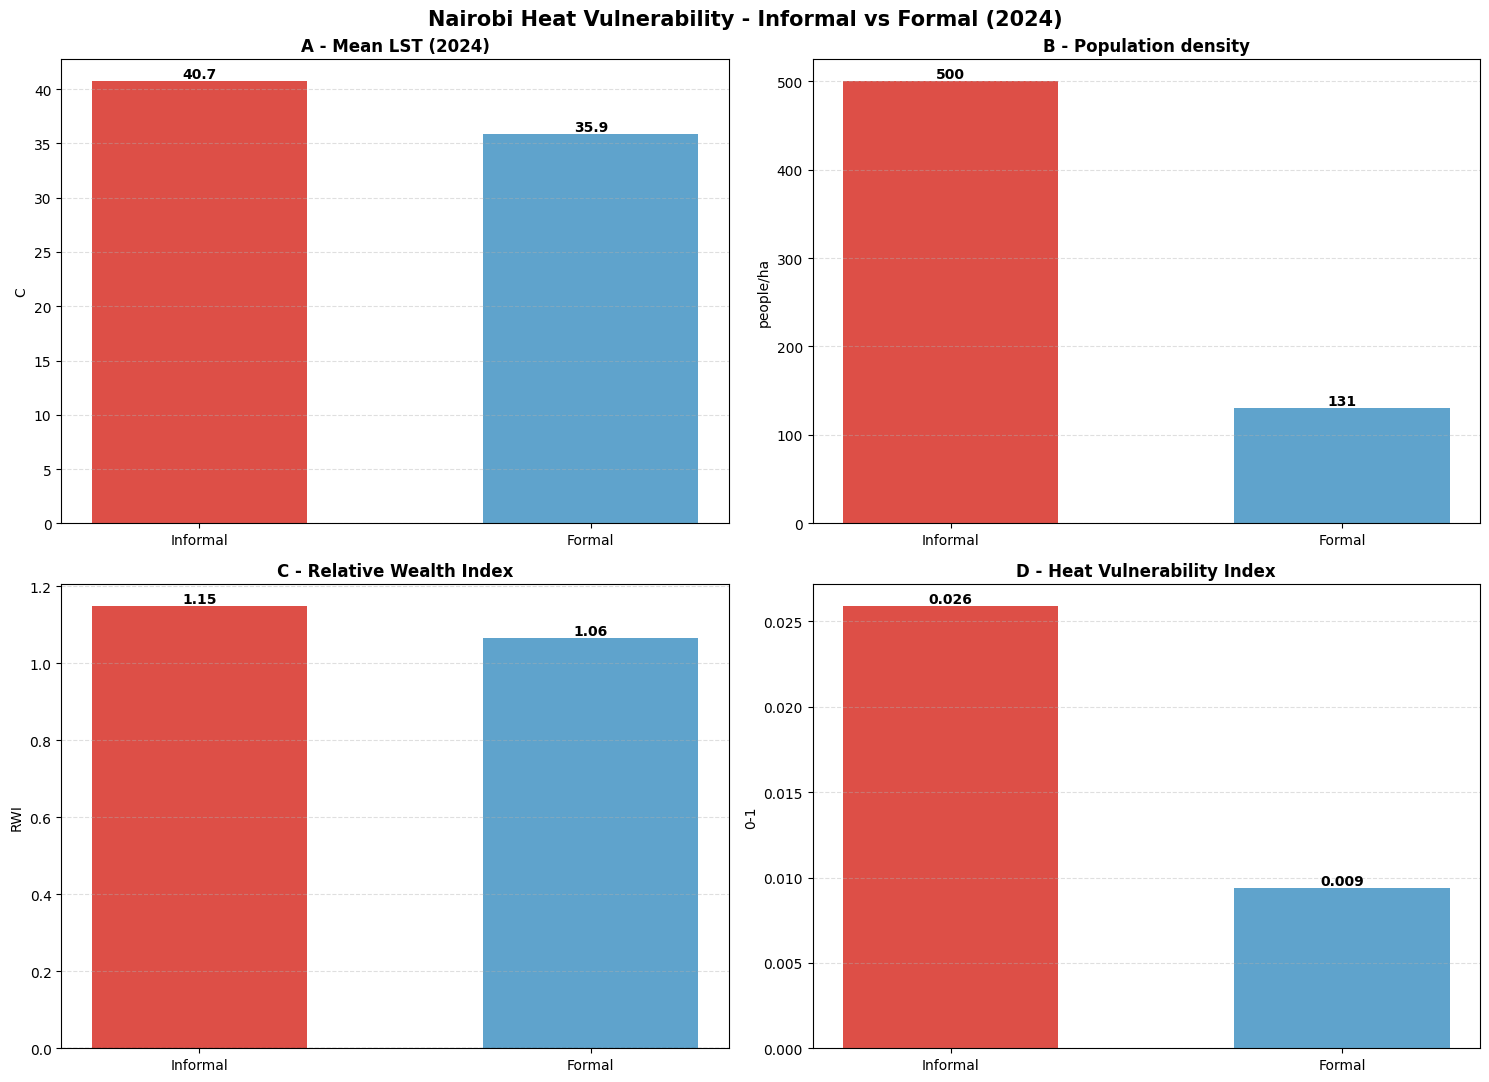

All outputs -> results/statistics/


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Nairobi Heat Vulnerability - Informal vs Formal (2024)", fontsize=15, fontweight="bold")
zl = ZONES; cl = [COLORS[z] for z in zl]

def panel(ax, vals, title, ylab, fmt="{:.1f}"):
    bars = ax.bar(["Informal", "Formal"], vals, color=cl, alpha=0.85, width=0.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v, fmt.format(v), ha="center", va="bottom", fontweight="bold")
    ax.set_title(title, fontweight="bold"); ax.set_ylabel(ylab); ax.grid(axis="y", ls="--", alpha=0.4)

panel(axes[0,0], [summary_df[summary_df.zone==z]["lst_mean_C"].values[0] for z in zl],
      "A - Mean LST (2024)", "C", "{:.1f}")
if "density_per_ha" in summary_df:
    panel(axes[0,1], [summary_df[summary_df.zone==z]["density_per_ha"].values[0] for z in zl],
          "B - Population density", "people/ha", "{:.0f}")
if "rwi_mean" in summary_df:
    panel(axes[1,0], [summary_df[summary_df.zone==z]["rwi_mean"].values[0] for z in zl],
          "C - Relative Wealth Index", "RWI", "{:.2f}")
    axes[1,0].axhline(0, color="black", lw=0.8, ls="--")
panel(axes[1,1], [summary_df[summary_df.zone==z]["vulnerability"].values[0] for z in zl],
      "D - Heat Vulnerability Index", "0-1", "{:.3f}")
plt.tight_layout(); fig.savefig(os.path.join(STATS_DIR, "summary_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()
print("All outputs -> results/statistics/")